In [3]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.model_selection import train_test_split
from sklearn.linear_model import LinearRegression
from sklearn.ensemble import RandomForestRegressor
from sklearn.metrics import mean_absolute_error
from sklearn.metrics import mean_squared_error
from sklearn.metrics import r2_score


In [4]:
df=pd.read_csv("C:\\Data\\Housing.csv")
df.head(10)

,price,area,bedrooms,bathrooms,stories,mainroad,guestroom,basement,hotwaterheating,airconditioning,parking,prefarea,furnishingstatus
0,13300000,7420,4,2,3,yes,no,no,no,yes,2,yes,furnished
1,12250000,8960,4,4,4,yes,no,no,no,yes,3,no,furnished
2,12250000,9960,3,2,2,yes,no,yes,no,no,2,yes,semi-furnished
3,12215000,7500,4,2,2,yes,no,yes,no,yes,3,yes,furnished
4,11410000,7420,4,1,2,yes,yes,yes,no,yes,2,no,furnished
5,10850000,7500,3,3,1,yes,no,yes,no,yes,2,yes,semi-furnished
6,10150000,8580,4,3,4,yes,no,no,no,yes,2,yes,semi-furnished
7,10150000,16200,5,3,2,yes,no,no,no,no,0,no,unfurnished
8,9870000,8100,4,1,2,yes,yes,yes,no,yes,2,yes,furnished
9,9800000,5750,3,2,4,yes,yes,no,no,yes,1,yes,unfurnished


In [5]:
df.shape

(545, 13)

In [6]:
df.columns

Index(['price', 'area', 'bedrooms', 'bathrooms', 'stories', 'mainroad',
       'guestroom', 'basement', 'hotwaterheating', 'airconditioning',
       'parking', 'prefarea', 'furnishingstatus'],
      dtype='object')

In [7]:
#target= price and all other columns are features

In [8]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 545 entries, 0 to 544
Data columns (total 13 columns):
 #   Column            Non-Null Count  Dtype 
---  ------            --------------  ----- 
 0   price             545 non-null    int64 
 1   area              545 non-null    int64 
 2   bedrooms          545 non-null    int64 
 3   bathrooms         545 non-null    int64 
 4   stories           545 non-null    int64 
 5   mainroad          545 non-null    object
 6   guestroom         545 non-null    object
 7   basement          545 non-null    object
 8   hotwaterheating   545 non-null    object
 9   airconditioning   545 non-null    object
 10  parking           545 non-null    int64 
 11  prefarea          545 non-null    object
 12  furnishingstatus  545 non-null    object
dtypes: int64(6), object(7)
memory usage: 55.5+ KB


In [9]:
df.isnull().sum()

price               0
area                0
bedrooms            0
bathrooms           0
stories             0
mainroad            0
guestroom           0
basement            0
hotwaterheating     0
airconditioning     0
parking             0
prefarea            0
furnishingstatus    0
dtype: int64

In [10]:
df.describe()

,price,area,bedrooms,bathrooms,stories,parking
count,5.450000e+02,545.000000,545.000000,545.000000,545.000000,545.000000
mean,4.766729e+06,5150.541284,2.965138,1.286239,1.805505,0.693578
std,1.870440e+06,2170.141023,0.738064,0.502470,0.867492,0.861586
min,1.750000e+06,1650.000000,1.000000,1.000000,1.000000,0.000000
25%,3.430000e+06,3600.000000,2.000000,1.000000,1.000000,0.000000
50%,4.340000e+06,4600.000000,3.000000,1.000000,2.000000,0.000000
75%,5.740000e+06,6360.000000,3.000000,2.000000,2.000000,1.000000
max,1.330000e+07,16200.000000,6.000000,4.000000,4.000000,3.000000


In [11]:
df.duplicated().sum()

0

In [12]:
df.select_dtypes(include='object').columns

Index(['mainroad', 'guestroom', 'basement', 'hotwaterheating',
       'airconditioning', 'prefarea', 'furnishingstatus'],
      dtype='object')

In [13]:
df = pd.get_dummies(df, drop_first=True)
df.head()

,price,area,bedrooms,bathrooms,stories,parking,mainroad_yes,guestroom_yes,basement_yes,hotwaterheating_yes,airconditioning_yes,prefarea_yes,furnishingstatus_semi-furnished,furnishingstatus_unfurnished
0,13300000,7420,4,2,3,2,True,False,False,False,True,True,False,False
1,12250000,8960,4,4,4,3,True,False,False,False,True,False,False,False
2,12250000,9960,3,2,2,2,True,False,True,False,False,True,True,False
3,12215000,7500,4,2,2,3,True,False,True,False,True,True,False,False
4,11410000,7420,4,1,2,2,True,True,True,False,True,False,False,False


In [14]:
X = df.drop("price", axis=1)
y = df["price"]

In [15]:
X_train, X_test, y_train, y_test = train_test_split(X,y,test_size=0.2,random_state=42)

In [16]:
lr = LinearRegression()
lr.fit(X_train, y_train)

LinearRegression()

In [17]:
y_pred_lr = lr.predict(X_test)

In [18]:
mae_lr = mean_absolute_error(y_test, y_pred_lr)
mae_lr

970043.4039201641

In [19]:
rmse_lr = np.sqrt(mean_squared_error(y_test, y_pred_lr))
rmse_lr

1324506.9600914388

In [20]:
r2_lr = r2_score(y_test, y_pred_lr)
r2_lr

0.6529242642153182

In [21]:
print("MAE:", mae_lr)
print("RMSE:", rmse_lr)
print("R2:", r2_lr)

MAE: 970043.4039201641
RMSE: 1324506.9600914388
R2: 0.6529242642153182


In [22]:
rf = RandomForestRegressor(n_estimators=100,random_state=42)
rf.fit(X_train, y_train)

RandomForestRegressor(random_state=42)

In [23]:
y_pred_rf = rf.predict(X_test)

In [24]:
mae_rf = mean_absolute_error(y_test, y_pred_rf)
mae_rf

1021546.0353211008

In [25]:
rmse_rf = np.sqrt(mean_squared_error(y_test, y_pred_rf))
rmse_rf

1400565.9728553821

In [26]:
r2_rf = r2_score(y_test, y_pred_rf)
r2_rf

0.611918531405699

In [27]:
print("MAE:", mae_rf)
print("RMSE:", rmse_rf)
print("R2:", r2_rf)

MAE: 1021546.0353211008
RMSE: 1400565.9728553821
R2: 0.611918531405699


In [28]:
comparison = pd.DataFrame({
    "Model":["Linear Regression","Random Forest"],
    "MAE":[mae_lr, mae_rf],
    "RMSE":[rmse_lr, rmse_rf],
    "R2":[r2_lr, r2_rf]
})

comparison

,Model,MAE,RMSE,R2
0,Linear Regression,9.700434e+05,1.324507e+06,0.652924
1,Random Forest,1.021546e+06,1.400566e+06,0.611919


In [29]:
# Visualization

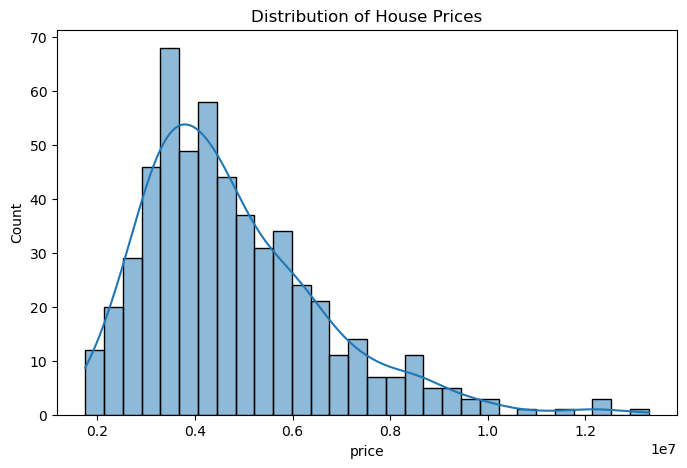

In [30]:
plt.figure(figsize=(8,5))
sns.histplot(df["price"],bins=30,kde=True)
plt.title("Distribution of House Prices")
plt.show()

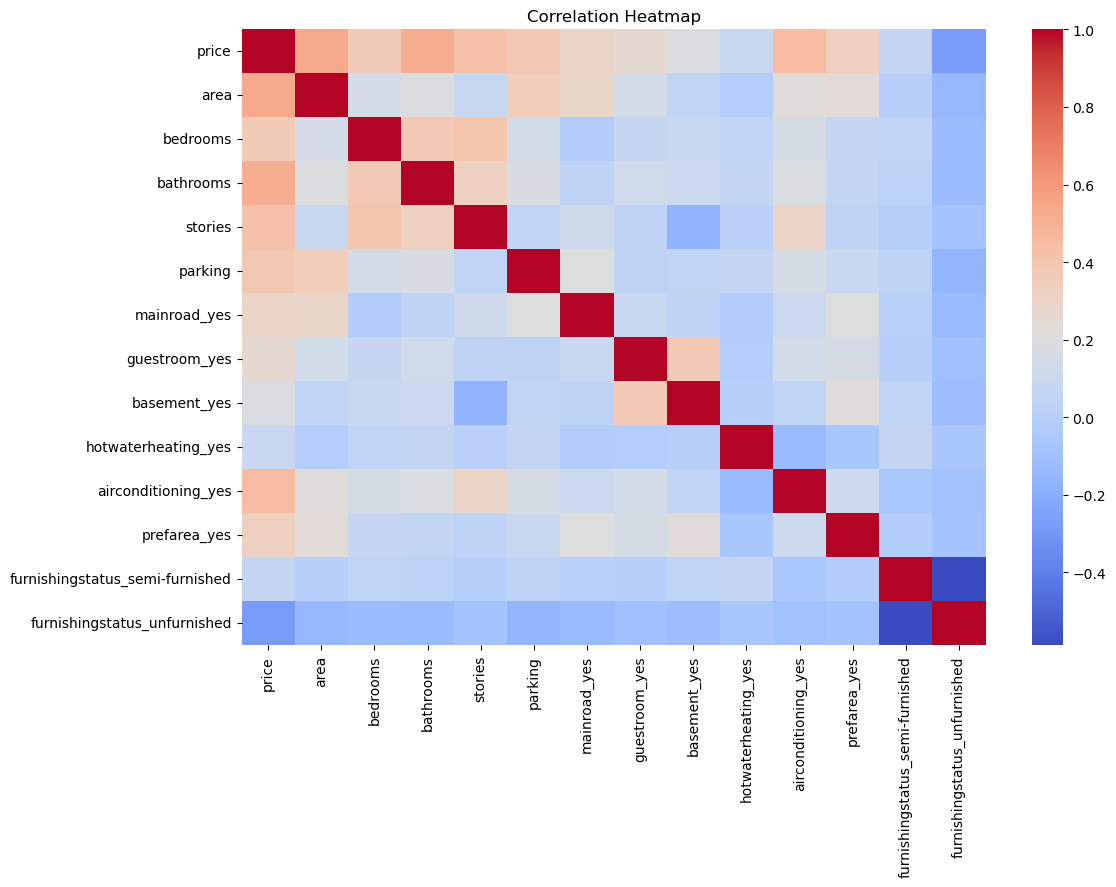

In [31]:
plt.figure(figsize=(12,8))
sns.heatmap(df.corr(),cmap="coolwarm")
plt.title("Correlation Heatmap")
plt.show()

In [32]:
df.corr()["price"].sort_values(
    ascending=False
)

price                              1.000000
area                               0.535997
bathrooms                          0.517545
airconditioning_yes                0.452954
stories                            0.420712
parking                            0.384394
bedrooms                           0.366494
prefarea_yes                       0.329777
mainroad_yes                       0.296898
guestroom_yes                      0.255517
basement_yes                       0.187057
hotwaterheating_yes                0.093073
furnishingstatus_semi-furnished    0.063656
furnishingstatus_unfurnished      -0.280587
Name: price, dtype: float64

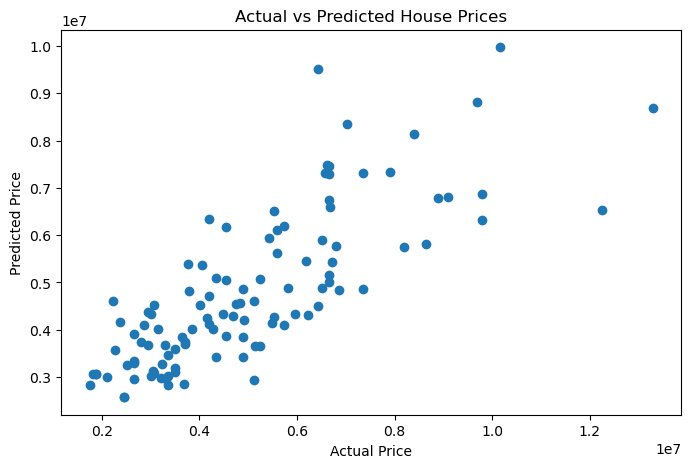

In [33]:
plt.figure(figsize=(8,5))
plt.scatter(y_test, y_pred_rf)
plt.xlabel("Actual Price")
plt.ylabel("Predicted Price")
plt.title("Actual vs Predicted House Prices")
plt.show()

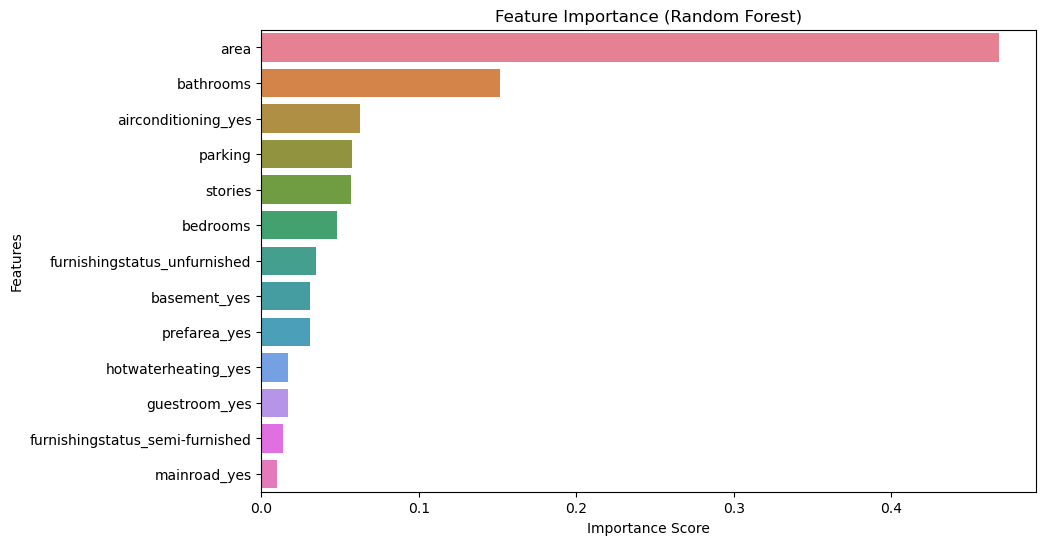

In [35]:
feature_importance = pd.DataFrame({'Feature': X.columns,'Importance': rf.feature_importances_})
feature_importance = feature_importance.sort_values(by='Importance',ascending=False)
plt.figure(figsize=(10,6))
sns.barplot(x='Importance',y='Feature',data=feature_importance,hue='Feature',legend=False)
plt.title('Feature Importance (Random Forest)')
plt.xlabel('Importance Score')
plt.ylabel('Features')
plt.show()

In [ ]:
# final insights and summary
The housing dataset contained 545 records with no missing values or duplicate entries. 
Correlation analysis revealed that area, bathrooms, air conditioning, stories, and parking are the most influential factors affecting house prices.
Two machine learning models were trained to predict house prices, and Linear Regression achieved the best performance with an R² score of 0.653. 
This means the model can explain approximately 65% of the variation in house prices, providing reasonably accurate predictions.
The analysis also showed that larger houses with better amenities and locations tend to command higher prices.
Based on these findings, real estate businesses should focus on properties with larger areas, modern facilities, and preferred locations to maximize property value and attract buyers.